# Homework 1 part 1 - Deep Learning Winter 2024

Student 1: Samih Warwar 324888155

Student 2: Merry Shalabi 324007202

# Question 1

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Define transformations for the training set
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the training and test datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split the training dataset into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Data loaders for train, validation, and test sets
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 170M/170M [00:05<00:00, 28.8MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


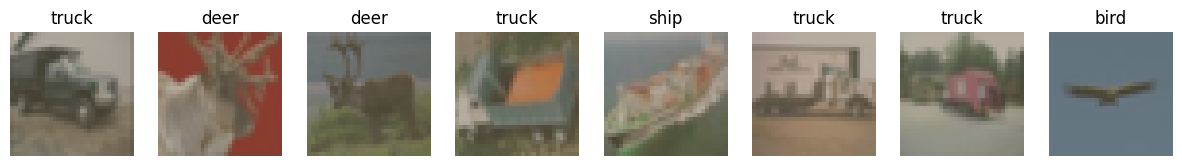

In [2]:
# Define a function to show images
def show_sample_images(dataset, class_names, num_images=8):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image, label = dataset[i]  # Get image and label
        image = image.permute(1, 2, 0)  # Change from (C, H, W) to (H, W, C)

        # Reverse normalization to display images correctly
        image = image * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        image = torch.clamp(image, 0, 1)  # Ensure valid range

        axes[i].imshow(image)
        axes[i].set_title(class_names[label])
        axes[i].axis("off")

    plt.show()

# Define class names based on your dataset
class_names = train_dataset.dataset.classes
# Display sample images
show_sample_images(train_dataset, class_names)

## Task 1 :

In [5]:
import torch.nn as nn
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Epoch 1/10, Train Loss: 1.5090, Train Accuracy: 46.15%, Validation Loss: 1.2809, Validation Accuracy: 54.52%
Epoch 2/10, Train Loss: 1.1925, Train Accuracy: 58.22%, Validation Loss: 1.1480, Validation Accuracy: 60.31%
Epoch 3/10, Train Loss: 1.0594, Train Accuracy: 62.94%, Validation Loss: 1.0646, Validation Accuracy: 63.13%
Epoch 4/10, Train Loss: 0.9751, Train Accuracy: 66.06%, Validation Loss: 1.0254, Validation Accuracy: 64.97%
Epoch 5/10, Train Loss: 0.9154, Train Accuracy: 68.27%, Validation Loss: 1.0086, Validation Accuracy: 65.32%
Epoch 6/10, Train Loss: 0.8722, Train Accuracy: 69.86%, Validation Loss: 0.9846, Validation Accuracy: 66.56%
Epoch 7/10, Train Loss: 0.8366, Train Accuracy: 70.86%, Validation Loss: 0.9921, Validation Accuracy: 65.92%
Epoch 8/10, Train Loss: 0.8073, Train Accuracy: 72.15%, Validation Loss: 0.9797, Validation Accuracy: 66.80%
Epoch 9/10, Train Loss: 0.7818, Train Accuracy: 72.83%, Validation Loss: 0.9831, Validation Accuracy: 66.19%
Epoch 10/10, Train 

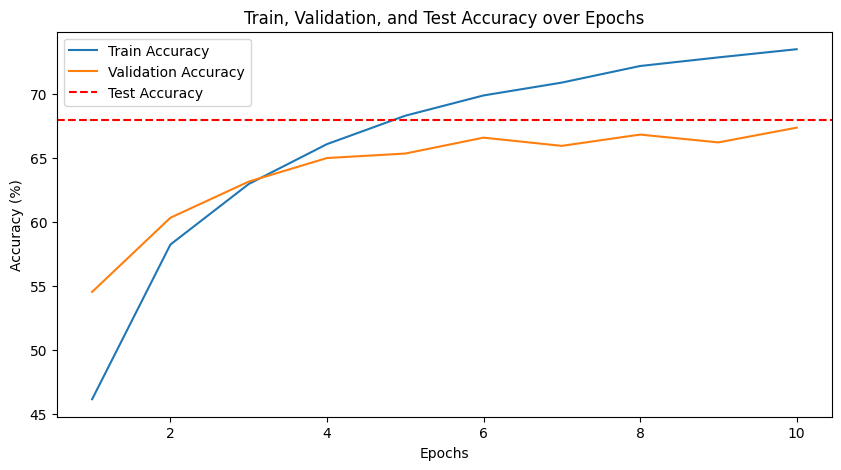

In [6]:
# Define the CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 10)  # 32 * (32*32)/(4*4) * 10

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)  # Flatten
        x = self.fc1(x)  # Fully connected layer
        return x

# Instantiate the model
model = SimpleCNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross entropy loss for classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # optimizer
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(100 * correct / total)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(100 * correct / total)

        # Print epoch results
        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train Loss: {train_losses[-1]:.4f}, "
              f"Train Accuracy: {train_accuracies[-1]:.2f}%, "
              f"Validation Loss: {val_losses[-1]:.4f}, "
              f"Validation Accuracy: {val_accuracies[-1]:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    return test_accuracy

# Train the model and get losses and accuracies
train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

# Test the model and get the accuracy
test_accuracy = test_model(model, test_loader)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), train_accuracies, label='Train Accuracy')
plt.plot(range(1, 11), val_accuracies, label='Validation Accuracy')
plt.axhline(y=test_accuracy, color='r', linestyle='--', label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Train, Validation, and Test Accuracy over Epochs')
plt.legend()
plt.show()


In [7]:
def denormalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    mean = torch.tensor(mean).view(3, 1, 1)  # Reshape to match (C, H, W)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean  # Reverse normalization
    img = torch.clamp(img, 0, 1)  # Ensure values are in range [0,1]
    return img

def visualize_test_image_by_index(model, test_loader, class_names, random_idx):
    model.eval()
    image, label = test_loader.dataset[random_idx]

    # Convert single image to batch format
    image = image.unsqueeze(0).to(device)

    # Get model prediction
    with torch.no_grad():
        output = model(image)
        _, predicted_label = torch.max(output, 1)

    # Convert image for display (undo normalization)
    image = image.squeeze().cpu()  # Remove batch dimension
    image = denormalize(image).numpy().transpose((1, 2, 0))  # Convert to (H, W, C)

    # Display the image
    plt.imshow(image)
    plt.title(f"True: {class_names[label]}, Predicted: {class_names[predicted_label.item()]}")
    plt.axis('off')
    plt.show()

# Function to visualize filters of the first convolutional layer
def visualize_filters(model):
    filters = model.conv1.weight.data.cpu().numpy()
    filters = (filters - filters.min()) / (filters.max() - filters.min())  # Normalize for visualization

    num_filters = filters.shape[0]
    fig, axes = plt.subplots(1, num_filters, figsize=(20, 5))
    for i in range(num_filters):
        axes[i].imshow(filters[i].transpose(1, 2, 0))  # (C, H, W) -> (H, W, C)
        axes[i].axis('off')
    plt.show()

# Function to visualize feature maps of the same test image
def visualize_feature_maps(model, random_idx):
    model.eval()
    image, _ = test_loader.dataset[random_idx]
    image = image.unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Get the output of the first conv layer
    with torch.no_grad():
        feature_maps = model.conv1(image)

    feature_maps = feature_maps.squeeze().cpu().numpy()  # Remove batch dimension and move to CPU

    num_feature_maps = feature_maps.shape[0]
    fig, axes = plt.subplots(1, num_feature_maps, figsize=(20, 5))
    for i in range(num_feature_maps):
        axes[i].imshow(feature_maps[i], cmap='viridis')  # Show feature map
        axes[i].axis('off')
    plt.show()

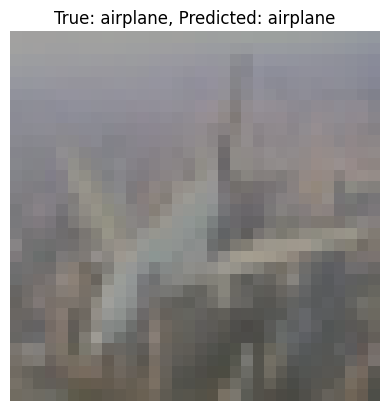

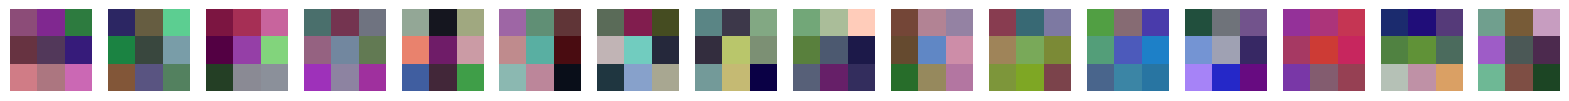

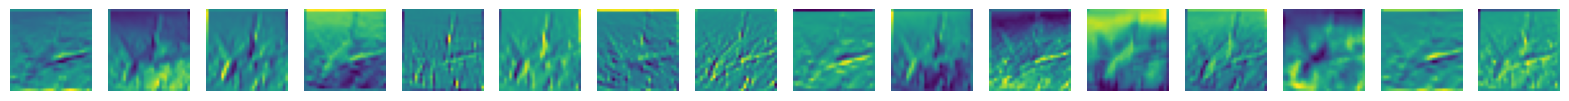

In [8]:
# Store the index of the chosen image
random_idx = random.randint(0, len(test_loader.dataset) - 1)

cifar10_classes = test_loader.dataset.classes
visualize_test_image_by_index(model, test_loader, cifar10_classes, random_idx)

# Visualize the filters after training
visualize_filters(model)

# Visualize feature maps for the same test image used previously
visualize_feature_maps(model, random_idx)


In [9]:
def print_model_details(model):
    print("Model Summary:")
    print(model)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total number of parameters: {total_params}")

# Print the details of the SimpleCNN model
print_model_details(model)


Model Summary:
SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=10, bias=True)
)
Total number of parameters: 25578


## Task 2:

Epoch 1/10, Train Loss: 1.5860, Validation Loss: 1.3394, Validation Accuracy: 51.65%
Epoch 2/10, Train Loss: 1.1701, Validation Loss: 1.0914, Validation Accuracy: 61.33%
Epoch 3/10, Train Loss: 0.9862, Validation Loss: 0.9787, Validation Accuracy: 65.56%
Epoch 4/10, Train Loss: 0.8563, Validation Loss: 0.9271, Validation Accuracy: 68.03%
Epoch 5/10, Train Loss: 0.7574, Validation Loss: 0.8858, Validation Accuracy: 69.08%
Epoch 6/10, Train Loss: 0.6818, Validation Loss: 0.8880, Validation Accuracy: 69.70%
Epoch 7/10, Train Loss: 0.6111, Validation Loss: 0.8824, Validation Accuracy: 70.04%
Epoch 8/10, Train Loss: 0.5489, Validation Loss: 0.8640, Validation Accuracy: 71.21%
Epoch 9/10, Train Loss: 0.4843, Validation Loss: 0.9103, Validation Accuracy: 70.62%
Epoch 10/10, Train Loss: 0.4373, Validation Loss: 0.9835, Validation Accuracy: 70.20%
Test Accuracy: 71.28%


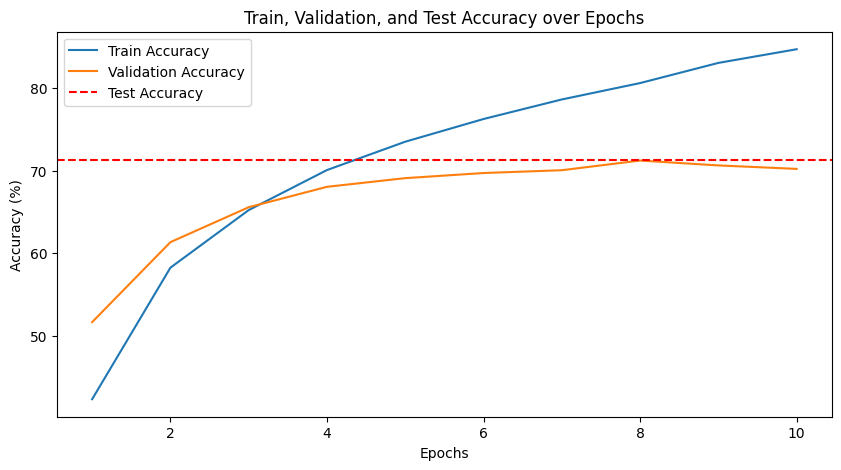

In [12]:
# Define model
class SimpleCNN_2(nn.Module):
    def __init__(self):
        super(SimpleCNN_2, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 2 * 2, 10)  # 32 * (32*32)/(4*4) * 10

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = x.view(-1, 128 * 2 * 2)  # Flatten
        x = self.fc1(x)  # Fully connected layer
        return x

# Instantiate the model
model = SimpleCNN_2().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross entropy loss for classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # optimizer


# Train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(100 * correct / total)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(100 * correct / total)

        # Print epoch results
        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train Loss: {running_loss/len(train_loader):.4f}, "
              f"Validation Loss: {val_loss/len(val_loader):.4f}, "
              f"Validation Accuracy: {100 * correct / total:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

# Test the model
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_accuracy = 100 * correct / total
    print(f"Test Accuracy: {100 * correct / total:.2f}%")
    return test_accuracy

# Train the model and get losses and accuracies
train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

# Test the model and get the accuracy
test_accuracy = test_model(model, test_loader)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), train_accuracies, label='Train Accuracy')
plt.plot(range(1, 11), val_accuracies, label='Validation Accuracy')
plt.axhline(y=test_accuracy, color='r', linestyle='--', label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Train, Validation, and Test Accuracy over Epochs')
plt.legend()
plt.show()


In [13]:
print_model_details(model)

Model Summary:
SimpleCNN_2(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=10, bias=True)
)
Total number of parameters: 102570


## Task 3:

Epoch 1/10, Train Loss: 1.7341, Train Accuracy: 37.06%, Validation Loss: 1.5330, Validation Accuracy: 44.19%
Epoch 2/10, Train Loss: 1.4634, Train Accuracy: 47.19%, Validation Loss: 1.4330, Validation Accuracy: 48.23%
Epoch 3/10, Train Loss: 1.3698, Train Accuracy: 50.77%, Validation Loss: 1.3782, Validation Accuracy: 50.81%
Epoch 4/10, Train Loss: 1.3094, Train Accuracy: 53.23%, Validation Loss: 1.3472, Validation Accuracy: 52.26%
Epoch 5/10, Train Loss: 1.2604, Train Accuracy: 55.27%, Validation Loss: 1.3006, Validation Accuracy: 53.91%
Epoch 6/10, Train Loss: 1.2222, Train Accuracy: 56.86%, Validation Loss: 1.2978, Validation Accuracy: 54.41%
Epoch 7/10, Train Loss: 1.1889, Train Accuracy: 58.07%, Validation Loss: 1.2732, Validation Accuracy: 55.50%
Epoch 8/10, Train Loss: 1.1688, Train Accuracy: 59.09%, Validation Loss: 1.2800, Validation Accuracy: 55.38%
Epoch 9/10, Train Loss: 1.1438, Train Accuracy: 59.78%, Validation Loss: 1.2618, Validation Accuracy: 56.08%
Epoch 10/10, Train 

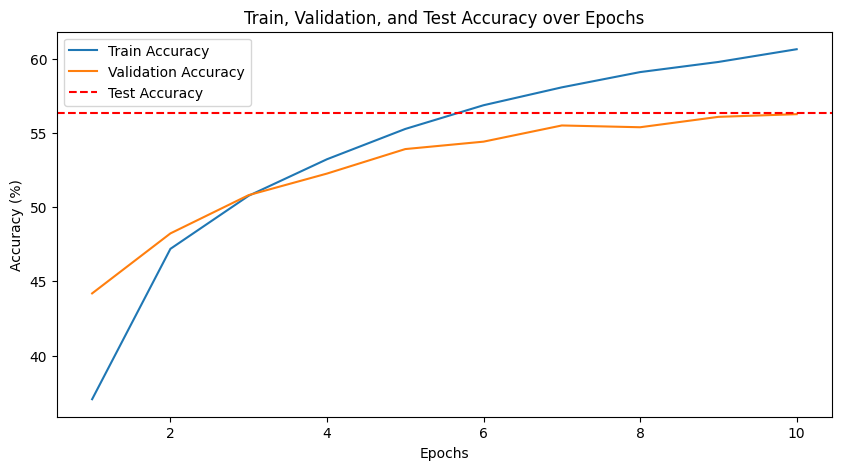

In [15]:
class SimpleCNN_3(nn.Module):
    def __init__(self):
        super(SimpleCNN_3, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=1) # (32-5+2*1)/2 +1 = 15.5 ==> 15/2 ==>7
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=1)  # (7-5+2)/2 +1=3/2 ==> 1
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 1 * 1, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 1 * 1)  # Flatten (adjust based on the actual shape printed)
        x = self.fc1(x)  # Fully connected layer
        return x

# Instantiate the model
model = SimpleCNN_3().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross entropy loss for classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # optimizer


# Train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(100 * correct / total)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(100 * correct / total)

        # Print epoch results
        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train Loss: {train_losses[-1]:.4f}, "
              f"Train Accuracy: {train_accuracies[-1]:.2f}%, "
              f"Validation Loss: {val_losses[-1]:.4f}, "
              f"Validation Accuracy: {val_accuracies[-1]:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

# Test the model
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_accuracy = 100 * correct / total
    print(f"Test Accuracy: {100 * correct / total:.2f}%")
    return test_accuracy

# Train the model and get losses and accuracies
train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

# Test the model and get the accuracy
test_accuracy = test_model(model, test_loader)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), train_accuracies, label='Train Accuracy')
plt.plot(range(1, 11), val_accuracies, label='Validation Accuracy')
plt.axhline(y=test_accuracy, color='r', linestyle='--', label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Train, Validation, and Test Accuracy over Epochs')
plt.legend()
plt.show()


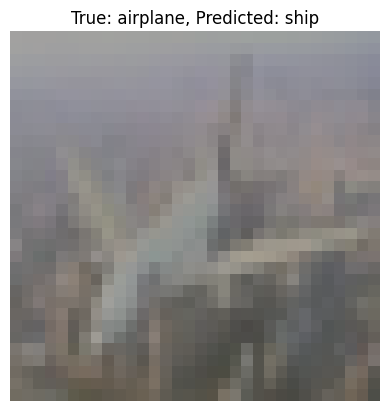

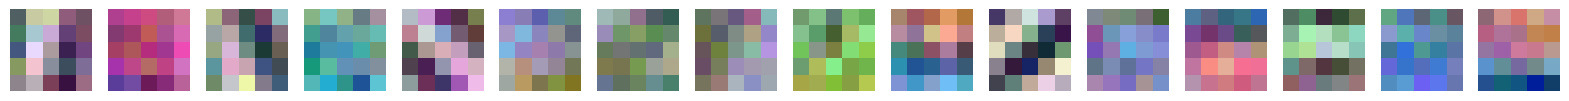

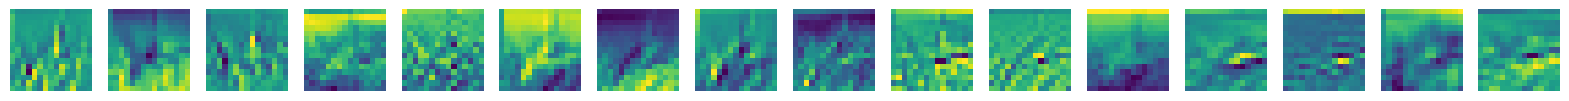

In [16]:
visualize_test_image_by_index(model, test_loader, cifar10_classes, random_idx)

# Visualize the filters after training
visualize_filters(model)

# Visualize feature maps for the same test image used previously
visualize_feature_maps(model, random_idx)

In [17]:
print_model_details(model)

Model Summary:
SimpleCNN_3(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32, out_features=10, bias=True)
)
Total number of parameters: 14378


## Task 4:

Epoch 1/10, Train Loss: 1.7060, Train Accuracy: 37.38%, Validation Loss: 1.4722, Validation Accuracy: 46.40%
Epoch 2/10, Train Loss: 1.3909, Train Accuracy: 49.72%, Validation Loss: 1.3484, Validation Accuracy: 51.48%
Epoch 3/10, Train Loss: 1.2505, Train Accuracy: 55.28%, Validation Loss: 1.2015, Validation Accuracy: 57.64%
Epoch 4/10, Train Loss: 1.1443, Train Accuracy: 59.02%, Validation Loss: 1.1703, Validation Accuracy: 59.24%
Epoch 5/10, Train Loss: 1.0573, Train Accuracy: 62.45%, Validation Loss: 1.0799, Validation Accuracy: 62.22%
Epoch 6/10, Train Loss: 0.9919, Train Accuracy: 64.63%, Validation Loss: 1.0128, Validation Accuracy: 64.41%
Epoch 7/10, Train Loss: 0.9250, Train Accuracy: 67.25%, Validation Loss: 0.9962, Validation Accuracy: 64.77%
Epoch 8/10, Train Loss: 0.8763, Train Accuracy: 69.05%, Validation Loss: 0.9927, Validation Accuracy: 65.45%
Epoch 9/10, Train Loss: 0.8277, Train Accuracy: 70.83%, Validation Loss: 0.9352, Validation Accuracy: 67.47%
Epoch 10/10, Train 

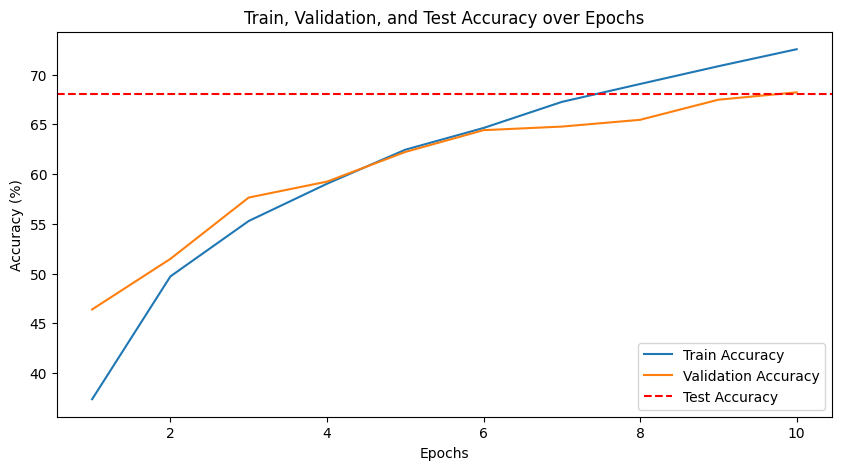

In [18]:
# Define model
class SimpleCNN_4(nn.Module):
    def __init__(self):
        super(SimpleCNN_4, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.AvgPool2d(2, 2)  # Change to AvgPool2d
        self.fc1 = nn.Linear(128 * 2 * 2, 10)  # 128 channels, 2x2 image size after pooling

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = x.view(-1, 128 * 2 * 2)  # Flatten
        x = self.fc1(x)  # Fully connected layer
        return x

# Instantiate the model
model = SimpleCNN_4().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross entropy loss for classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # optimizer


# Train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(100 * correct / total)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(100 * correct / total)

        # Print epoch results
        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train Loss: {train_losses[-1]:.4f}, "
              f"Train Accuracy: {train_accuracies[-1]:.2f}%, "
              f"Validation Loss: {val_losses[-1]:.4f}, "
              f"Validation Accuracy: {val_accuracies[-1]:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

# Test the model
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    return test_accuracy

# Train the model and get losses and accuracies
train_losses, val_losses, train_accuracies, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

# Test the model and get the accuracy
test_accuracy = test_model(model, test_loader)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), train_accuracies, label='Train Accuracy')
plt.plot(range(1, 11), val_accuracies, label='Validation Accuracy')
plt.axhline(y=test_accuracy, color='r', linestyle='--', label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Train, Validation, and Test Accuracy over Epochs')
plt.legend()
plt.show()


In [19]:
print_model_details(model)

Model Summary:
SimpleCNN_4(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=512, out_features=10, bias=True)
)
Total number of parameters: 102570


Explanation:<br>
We got better results in the second model becasue we added additinal layers therefore we have deeper network, in third model we changed the kernel size which made it too big for the artifacts that appear in the images which means the filters didnt learn as much as before therefore worst results.<br>
The difference between the the fourth model and the second one is the methood of pooling, and because on the fourth one used average rather than max we will not just point the stong features but will get the average which will get us worst results.  